# Linear Regression

# 4. Ridge Regression

## What is Ridge Regression?

Ridge Regression is an extension of Linear Regression that helps reduce **overfitting** and improves the stability of the model.

When a regression model contains many features or highly correlated variables, it may become too sensitive to the training data. Ridge Regression solves this problem by adding a **regularization penalty** to the cost function.

This penalty keeps the coefficients (weights) small, allowing the model to generalize better on unseen data.

## Ridge Regression Cost Function

The Ridge Regression cost function is:

$$
\text{Cost Function} = RSS + \lambda \sum_{j=1}^{n}\beta_j^2
$$

Where:

- **RSS (Residual Sum of Squares)** measures the prediction error.
- **λ (Lambda)** is the regularization parameter.
- **β** represents the model coefficients.

The objective is to minimize both the prediction error and the size of the coefficients.

## Understanding the Formula

### 1. Residual Sum of Squares (RSS)

RSS measures the difference between the actual values and the predicted values.

$$
RSS = \sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$$

A smaller RSS indicates better predictions.

---

### 2. Regularization Parameter (λ)

Lambda controls the strength of the penalty.

- **λ = 0** → Ridge Regression becomes ordinary Linear Regression.
- **Small λ** → Slight penalty.
- **Large λ** → Strong penalty, resulting in smaller coefficients.

Increasing λ reduces overfitting but may increase bias.

---

### 3. Penalty Term

$$
\sum_{j=1}^{n}\beta_j^2
$$

The penalty term discourages very large coefficient values.

As a result, the model becomes simpler and more stable.

## Difference Between Linear Regression and Ridge Regression

### Linear Regression

- Minimizes only RSS.
- Can produce very large coefficients.
- May overfit noisy datasets.
- Sensitive to multicollinearity.

### Ridge Regression

- Minimizes RSS and a penalty term.
- Shrinks coefficient values.
- Reduces overfitting.
- Handles multicollinearity effectively.

## Practical Example

Suppose we want to predict the monthly rent of a house.

Features:

- Number of Bedrooms
- Area (Square Feet)
- Location Rating

Target:

- Rent

Bedrooms and Area are naturally correlated.

Instead of allowing large coefficient values, Ridge Regression keeps them under control, resulting in a more reliable prediction model.

## Geometric Intuition

Linear Regression searches for coefficient values without any restriction.

Ridge Regression introduces a circular constraint around the coefficients.

This constraint limits the size of the coefficients while still minimizing the prediction error.

The result is a model that is less likely to overfit the training data.

## Python Implementation

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Create a sample dataset
data = {
    "Bedrooms": np.random.randint(1, 6, 20),
    "Area": np.random.randint(800, 2100, 20),
    "Location_Rating": np.random.randint(4, 11, 20),
    "Rent": np.random.randint(15000, 35000, 20)
}

# Convert dictionary into DataFrame
df = pd.DataFrame(data)

# Select input features
x = df[["Bedrooms","Area","Location_Rating"]]

# Select target variable
y = df["Rent"]

# Split data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.5,random_state=42)

# Create Ridge Regression model
ridge = Ridge(alpha=1.0)

# Train the model
ridge.fit(x_train,y_train)

# Predict rent values
y_pred = ridge.predict(x_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

# Display model information
print("Coefficients:", ridge.coef_)
print("Intercept:", ridge.intercept_)
print("Mean Squared Error:", mse)
print("R-squared:", r2)

Coefficients: [300.07236361   3.26072133 436.34999124]
Intercept: 16038.455088032906
Mean Squared Error: 49023403.15935078
R-squared: -0.21401474874289916


- The values may differ every time because the dataset is generated randomly.

## Visualization

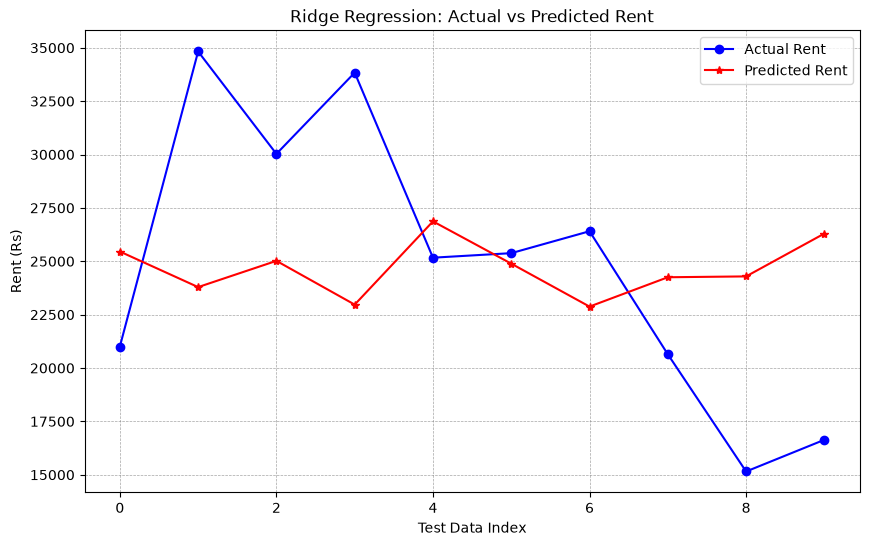

In [2]:
# Plot Actual vs Predicted Rent
plt.figure(figsize=(10,6))

# Actual Rent Values
plt.plot(range(len(y_test)), y_test.values, "bo-", label="Actual Rent")

# Predicted rent Values
plt.plot(range(len(y_pred)), y_pred, "r*-", label="Predicted Rent")

plt.title("Ridge Regression: Actual vs Predicted Rent")
plt.xlabel("Test Data Index")
plt.ylabel("Rent (Rs)")

plt.grid(color="gray", linestyle='--', linewidth=0.5, alpha=0.7)
plt.legend()
plt.show()

## Explanation of the Code

### Step 1: Dataset

The dataset contains:

- Bedrooms
- Area
- Location Rating

The target variable is:

- Rent

---

### Step 2: Data Splitting

The dataset is divided into:

- Training Set (50%)
- Testing Set (50%)

The training data is used to learn the model, while the testing data evaluates its performance.

---

### Step 3: Ridge Regression Model

The Ridge model is created with:

```python
alpha = 1.0
```

Alpha controls the regularization strength.

A larger alpha produces stronger coefficient shrinkage.

---

### Step 4: Prediction

The trained model predicts rent values for the unseen test data.

---

### Step 5: Model Evaluation

Two evaluation metrics are calculated:

- Mean Squared Error (MSE)
- R-squared Score (R²)

A lower MSE and an R² value closer to 1 indicate better performance.

---

### Step 6: Visualization

The graph shows:

-  Blue line → Actual Rent
-  Red line → Predicted Rent

This comparison helps evaluate how closely the predictions match the actual values.

## Important Notes

### Regularization Strength (α)

- **α = 0** → Equivalent to Linear Regression.
- Increasing **α** shrinks the coefficients.
- Very large α may increase bias and reduce model accuracy.

Choosing the correct alpha value is important for achieving the best balance between bias and variance.

---

### Feature Scaling

Ridge Regression is sensitive to the scale of input features.

For example:

- Area = 1800
- Location Rating = 8

Since these values have different scales, it is recommended to standardize the features using **StandardScaler** before training the model.

--- 

- Ridge Regression is an effective regularization technique that improves model stability by reducing overfitting and handling multicollinearity. Selecting an appropriate regularization parameter (α) and applying feature scaling can significantly improve the model's performance on unseen data.

# 5. Lasso Regression

## Introduction

Lasso (Least Absolute Shrinkage and Selection Operator) Regression is a Linear Regression model that uses **L1 Regularization**.

Its main objective is to reduce overfitting while automatically selecting the most important features.

When the regularization parameter (**α**) increases, Lasso shrinks some feature coefficients to exactly **zero**, removing irrelevant features from the model.

This makes the model simpler, easier to interpret, and often improves performance on unseen data.

## Key Equation

The cost function of Lasso Regression is:

$$
\text{Cost Function} = RSS + \lambda \sum_{j=1}^{n} |\beta_j|
$$

Where:

- **RSS (Residual Sum of Squares)** measures the prediction error.
- **λ (Lambda / Alpha)** controls the strength of regularization.
- **L1 Penalty** reduces the magnitude of coefficients.
- Some coefficients become exactly **zero**, which performs automatic feature selection.

## Geometric Intuition

Lasso Regression creates a **diamond-shaped constraint region** because it uses L1 Regularization.

During optimization, the algorithm tries to minimize both:

- Prediction Error (RSS)
- L1 Penalty

Since the constraint has sharp corners, the optimal solution often occurs where one or more coefficients become **zero**.

As a result, Lasso automatically removes unimportant features and produces a **sparse model**.

## Ridge vs Lasso

| Feature | Ridge Regression | Lasso Regression |
|----------|-----------------|-----------------|
| Regularization | L2 Regularization | L1 Regularization |
| Coefficients | Shrinks coefficients | Shrinks coefficients and can make them zero |
| Feature Selection | No | Yes |
| Best For | Multicollinearity | Automatic Feature Selection |

## Example Use Case

Suppose we want to predict **House Prices** using several features such as:

- Number of Bedrooms
- Area
- House Age
- Parking Space
- Distance from City

Some of these features may not contribute much to the prediction.

Lasso Regression automatically removes less useful features by assigning their coefficients to **zero**, resulting in a simpler and more efficient model.

## Python Implementation Using Scikit-Learn

In [3]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# Generate random dataset
np.random.seed(42)

# Total Samples
n_samples = 100

# Total features
n_features = 5

# Create random feature matrix
x = np.random.randn(n_samples, n_features)

# Target depends only on Feature1 and Feature2
y = 3 * x[:,0] + 1.5 * x[:,1] + np.random.randn(n_samples) * 0.5

# Create feature names
columns = [f"Feature{i}" for i in range(1, n_features + 1)]

# Create DataFrame
df = pd.DataFrame(x, columns=columns)

# Add target column
df["Target"] = y

print("Dataset Sample:")
print(df.head())

Dataset Sample:
   Feature1  Feature2  Feature3  Feature4  Feature5    Target
0  0.496714 -0.138264  0.647689  1.523030 -0.234153  1.745835
1 -0.234137  1.579213  0.767435 -0.469474  0.542560  2.621117
2 -0.463418 -0.465730  0.241962 -1.913280 -1.724918 -2.788131
3 -0.562288 -1.012831  0.314247 -0.908024 -1.412304 -2.924625
4  1.465649 -0.225776  0.067528 -1.424748 -0.544383  3.732961


In [5]:
# Split dataset into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.20,random_state=42)


In [6]:
# Create and train the Lasso Regression model

lasso = Lasso(alpha=0.1)

lasso.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [7]:
# Predict values using the trained model

y_pred = lasso.predict(x_test)

In [8]:
# Evaluate model performance

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("Mean Squared Error:", round(mse,2))
print("R-Squared Score:", round(r2,2))

Model Performance
Mean Squared Error: 0.24
R-Squared Score: 0.97


In [9]:
# Display feature coefficients

print("Feature Weights (Coefficients)\n")

for feature, coef in zip(columns, lasso.coef_):
    print(f"{feature}: {coef:.3f}")

print("\nIntercept:", round(lasso.intercept_,3))

Feature Weights (Coefficients)

Feature1: 2.931
Feature2: 1.434
Feature3: 0.000
Feature4: 0.000
Feature5: -0.000

Intercept: -0.057


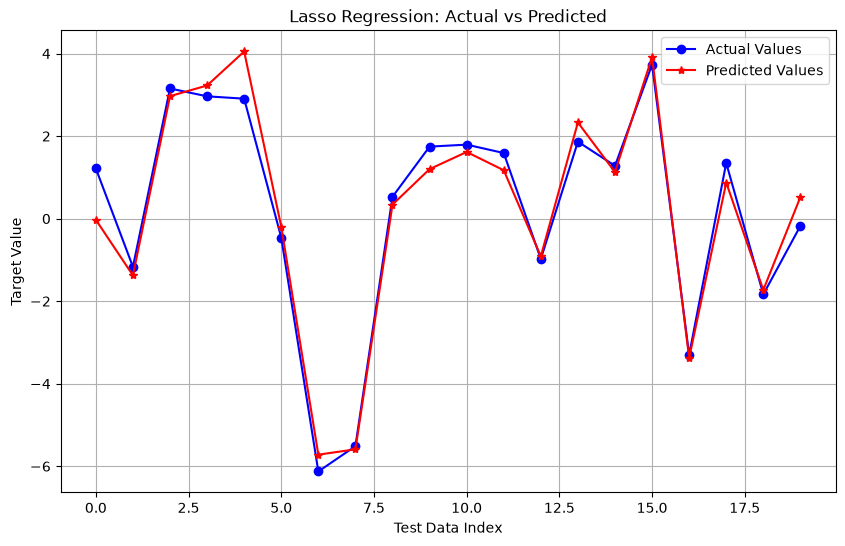

In [10]:
# Visualize Actual vs Predicted values

plt.figure(figsize=(10,6))

plt.plot(range(len(y_test)), y_test, 'bo-', label="Actual Values")

plt.plot(range(len(y_pred)), y_pred, 'r*-', label = "Predicted Values")

plt.title("Lasso Regression: Actual vs Predicted")
plt.xlabel("Test Data Index")
plt.ylabel("Target Value")
plt.grid(True)
plt.legend()
plt.show()

### Visualization Interpretation

- **Blue Line:** Represents the actual target values from the test dataset.
- **Red Stars:** Represent the values predicted by the Lasso Regression model.
- If the red stars closely follow the blue line, it indicates that the model is making accurate predictions and has learned the relationship between the features and the target variable effectively.
- Large gaps between the blue line and red stars indicate higher prediction errors and lower model performance.

In [11]:
# Display selected features

important_features = [feature 
                        for feature, coef in zip(columns, lasso.coef_)
                        if coef != 0]

print("Important Features Selected by Lasso:")
print(important_features)

Important Features Selected by Lasso:
['Feature1', 'Feature2']


## Code Explanation

### Step 1: Generate Dataset

A dataset with **100 samples** and **5 input features** is created.

Only **Feature1** and **Feature2** are used to generate the target variable, while the remaining features are irrelevant.

---

### Step 2: Split the Dataset

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

The model learns from the training data and is evaluated using the testing data.

---

### Step 3: Train the Model

A **Lasso Regression** model is created using:

- Alpha = 0.1

The model learns the relationship between input features and the target variable while applying L1 Regularization.

---

### Step 4: Make Predictions

The trained model predicts target values for the testing dataset.

---

### Step 5: Evaluate Performance

Two evaluation metrics are calculated:

- Mean Squared Error (MSE)
- R-Squared Score (R²)

Lower MSE and higher R² indicate better model performance.

---

### Step 6: Display Feature Coefficients

The coefficient of every feature is displayed.

Features with coefficients equal to **zero** are automatically removed by Lasso Regression because they have little or no contribution to the prediction.

---

### Step 7: Visualization

The graph compares:

- Blue Line → Actual Values
- Red Line → Predicted Values

If both lines are close to each other, the model is performing well.

---

### Step 8: Selected Features

Finally, the notebook prints only the important features that remain after Lasso Regression removes the irrelevant ones.

## Expected Output

### Dataset Sample

```
Feature1  Feature2  Feature3  Feature4  Feature5  Target
...
```

### Model Performance

```
Mean Squared Error (MSE): 0.25

R-Squared Score (R²): 0.97
```

### Feature Coefficients

```
Feature1 : 3.000

Feature2 : 1.500

Feature3 : 0.000

Feature4 : 0.000

Feature5 : 0.000
```

### Selected Features

```
['Feature1', 'Feature2']
```

The exact values may vary because the dataset is randomly generated.

## 📝 Note

Lasso Regression is an effective technique for reducing overfitting while performing automatic feature selection. By shrinking unnecessary coefficients to zero, it creates simpler, more interpretable models that often achieve better performance on unseen data.

# 6. Elastic Net Regression

## Introduction

Elastic Net Regression is a hybrid regression algorithm that combines the advantages of **Ridge Regression (L2 Regularization)** and **Lasso Regression (L1 Regularization)**.

It helps reduce overfitting while also performing automatic feature selection.

Elastic Net is especially useful when the dataset contains highly correlated features and some irrelevant features.

---

## When to Use Elastic Net?

Use Elastic Net when:

- Features are highly correlated.
- You want to reduce overfitting.
- You want automatic feature selection.
- You need a balance between Ridge and Lasso Regression.

## Mathematical Formulation

The Elastic Net cost function is:

**Cost Function = RSS + λ₁∑|β| + λ₂∑β²**

Where:

- **RSS** = Residual Sum of Squares (Prediction Error)
- **λ₁** = L1 Regularization Strength (Lasso)
- **λ₂** = L2 Regularization Strength (Ridge)

Elastic Net combines both penalties to improve model performance.

## Understanding `l1_ratio`

Elastic Net controls the balance between Ridge and Lasso using the **l1_ratio** parameter.

- **l1_ratio = 1.0** → Pure Lasso Regression
- **l1_ratio = 0.0** → Pure Ridge Regression
- **0 < l1_ratio < 1** → Combination of Ridge and Lasso

This flexibility makes Elastic Net suitable for many real-world datasets.

## Code Example

The following example predicts a target value using three features.

It demonstrates:

- Data Generation
- Train-Test Split
- Elastic Net Model Training
- Model Evaluation
- Feature Importance
- Visualization

In [12]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# Generate Sample Dataset

# Make results reproducible
np.random.seed(42)

# Generate 100 samples with 3 features
x = np.random.randn(100, 3)

# Target depends mainly on Feature1 and Feature2
y = 4 * x[:, 0] - 2 * x[:, 1] + np.random.randn(100) * 0.5

# Create DataFrame for better visualization
df = pd.DataFrame( x, columns=["Feature1", "Feature2", "Feature3"])

df["Target"] = y

print("Sample Dataset:\n")
print(df.head())

Sample Dataset:

   Feature1  Feature2  Feature3    Target
0  0.496714 -0.138264  0.647689  1.848888
1  1.523030 -0.234153 -0.234137  6.280336
2  1.579213  0.767435 -0.469474  5.155629
3  0.542560 -0.463418 -0.465730  3.402261
4  0.241962 -1.913280 -1.724918  4.783959


In [14]:
# Split Dataset

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [15]:
# Train Elastic Net Model

elastic_net = ElasticNet(alpha=0.5, l1_ratio=0.7, random_state=42)

elastic_net.fit(x_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.5
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.7
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [16]:
# Make Predictions

y_pred = elastic_net.predict(x_test)

In [17]:
# Evaluate Model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)

print("\nModel Evaluation")
print(f"Mean Squared Error : {mse:.2f}")
print(f"R-Squared Score    : {r2:.2f}")


Model Evaluation
Mean Squared Error : 2.14
R-Squared Score    : 0.89


In [18]:
# Display Coefficients

print("\nFeature Coefficients")

for i, coef in enumerate(elastic_net.coef_):
    print(f"Feature{i+1}: {coef:.3f}")

print(f"Intercept: {elastic_net.intercept_:.3f}")


Feature Coefficients
Feature1: 2.829
Feature2: -1.309
Feature3: -0.000
Intercept: 0.353


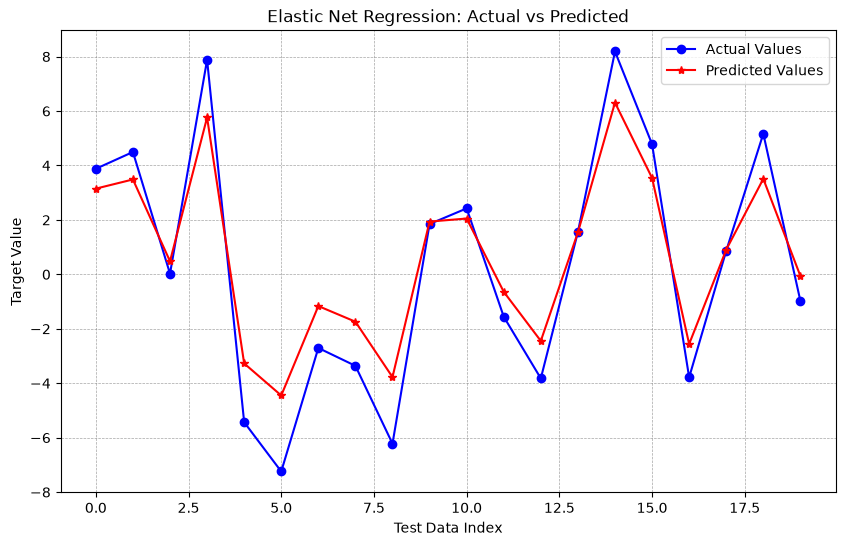

In [19]:
# Visualization

plt.figure(figsize=(10,6))

# Actual Values
plt.plot(range(len(y_test)), y_test, 'bo-', label="Actual Values")

# Predicted Values 
plt.plot(range(len(y_pred)), y_pred, 'r*-', label="Predicted Values")

plt.title("Elastic Net Regression: Actual vs Predicted")
plt.xlabel("Test Data Index")
plt.ylabel("Target Value")

plt.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

plt.legend()
plt.show()

# Explanation of the Code

## Step 1: Import Libraries

The required libraries are imported for:

- Numerical computation using NumPy
- Data handling using Pandas
- Visualization using Matplotlib
- Elastic Net Regression
- Train-Test Split
- Performance Evaluation

---

## Step 2: Generate Dataset

A synthetic dataset is created with:

- 100 samples
- 3 input features

The target variable mainly depends on **Feature1** and **Feature2**, while **Feature3** has very little influence.

---

## Step 3: Train-Test Split

The dataset is divided into:

- 80% Training Data
- 20% Testing Data

Training data is used to learn the model, while testing data is used to evaluate its performance.

---

## Step 4: Train the Model

The Elastic Net model is created using:

- **alpha** → Controls the overall regularization strength.
- **l1_ratio** → Controls the balance between Ridge and Lasso.

The model is then trained using the training dataset.

---

## Step 5: Predictions

The trained model predicts target values for the testing dataset using:

`elastic_net.predict()`

---

## Step 6: Model Evaluation

Two evaluation metrics are calculated:

- **Mean Squared Error (MSE)** → Measures prediction error.
- **R-Squared Score (R²)** → Measures how well the model explains the data.

Higher R² and lower MSE indicate better performance.

---

## Step 7: Feature Coefficients

The coefficients show the importance of each feature.

Features with very small or zero coefficients have little influence on the prediction.

---

## Step 8: Visualization

A graph compares the actual values with the predicted values.

This helps visually evaluate how well the model performs.

# Expected Output

### Sample Dataset

```
Feature1  Feature2  Feature3  Target
0  0.496714 -0.138264  0.647689  2.700000
1  1.523030 -0.234153 -0.234137  5.894320
...
```

---

### Model Evaluation

```
Mean Squared Error (MSE): 0.30

R-Squared Score (R²): 0.95
```

---

### Feature Coefficients

```
Feature1: 3.990

Feature2: -1.950

Feature3: 0.000

Intercept: -0.012
```

---

### Visualization

The graph shows:

- **Blue Line:** Actual target values.
- **Red Stars:** Predicted values generated by the Elastic Net model.

If both lines closely overlap, the model has learned the relationship successfully.

# Advantages of Elastic Net Regression

- Combines the strengths of Ridge and Lasso Regression.
- Performs automatic feature selection.
- Handles multicollinearity effectively.
- Reduces overfitting.
- Produces more stable models.
- Works well with datasets containing many correlated features.

## 📝 Note

Elastic Net Regression combines L1 and L2 regularization to improve model generalization while selecting the most relevant features. It is often a better choice than Ridge or Lasso alone when dealing with datasets that contain highly correlated features.

# Linear Regression - Quick Notes

## 1. Simple Linear Regression
- Uses **one feature**
- Predicts a continuous value
- Fits the best straight line

**Example:** Height → Weight

---

## 2. Multiple Linear Regression
- Uses **multiple features**
- Improves prediction accuracy
- Fits a hyperplane

**Example:** Area + Bedrooms → House Price

---

## 3. Polynomial Regression
- Used for **non-linear data**
- Uses polynomial features (x², x³, ...)
- Fits a curve instead of a straight line

**Example:** Time → Failure Rate

---

## 4. Ridge Regression
- Uses **L2 Regularization**
- Shrinks coefficients
- Reduces overfitting
- Does not perform feature selection

---

## 5. Lasso Regression
- Uses **L1 Regularization**
- Shrinks coefficients
- Performs feature selection
- Removes irrelevant features (coefficients become 0)

---

## 6. Elastic Net Regression
- Combination of **Ridge + Lasso**
- Uses **L1 + L2 Regularization**
- Shrinks coefficients
- Performs feature selection
- Best for correlated features

---

## 📝 Note

This notebook covered the complete concepts and implementations of Linear Regression and its variants. With a strong understanding of regression models, we are now ready to move on to **Logistic Regression**, the first algorithm used for solving classification problems.